In [4]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('agg')
import matplotlib.pyplot as plt
import os
# from tqdm.notebook import  tqdm
from tqdm import  tqdm
import talib
import datetime
import math
import  mplfinance as mpf
from collections import Counter

import sys
sys.path.append('../../DataSource/同花顺')
import datasource
sys.path.append('../..')
import Utils
# 这个是筛选多少天上涨多少的，
codes = datasource.get_codes()
print(f'股票数量:{len(codes)},第一支股票:{codes[0]}')
code = codes[0]
dt = datasource.getData(code)
dt.head()

股票数量:6974,第一支股票:000001


,Id,Code,Date,Open,High,Low,Close,Amount,Volume
0,1,000001,2014-01-02 00:00:00,12.12,12.30,12.05,12.23,596223740.0,48991089.0
1,2,000001,2014-01-03 00:00:00,12.15,12.16,11.78,11.93,656631300.0,55111484.0
2,3,000001,2014-01-06 00:00:00,11.89,12.00,11.50,11.67,679280380.0,58211823.0
3,4,000001,2014-01-07 00:00:00,11.53,11.76,11.51,11.63,393977580.0,33840749.0
4,5,000001,2014-01-08 00:00:00,11.64,11.95,11.53,11.76,538436170.0,45776816.0


In [6]:
# 我这里要计算天数
dt['preClose'] = dt['Close'].shift() # 默认向下移动1个
dt['UpDown'] = dt['Close'] > dt['preClose'] # 查看是否上涨的
ids = (dt['UpDown'] != dt['UpDown'].shift()).cumsum() 
counts = dt['UpDown'].groupby(ids).transform('size')
result = counts[ids.drop_duplicates().index].tolist()
count_arr = Counter(result)
count_arr

Counter({1: 718,
         2: 379,
         3: 145,
         4: 82,
         5: 42,
         6: 23,
         7: 12,
         8: 5,
         10: 3,
         12: 1})

In [7]:
# 所有股票的攻击
dict_count = {}
for i in tqdm(range(len(codes))):
    code = codes[i]
    dt = datasource.getData(code, '2024-01-01')
    dt['preClose'] = dt['Close'].shift() # 默认向下移动1个
    dt['UpDown'] = dt['Close'] > dt['preClose'] # 查看是否上涨的
    ids = (dt['UpDown'] != dt['UpDown'].shift()).cumsum() 
    counts = dt['UpDown'].groupby(ids).transform('size')
    result = counts[ids.drop_duplicates().index].tolist()
    count_arr = Counter(result)
    # 然后添加到
    for i in count_arr:
        if i in dict_count:
            dict_count[i] += count_arr[i]
        else:
            dict_count[i] = count_arr[i]

100%|█████████████████████████████████████████████████████████████████████████████| 6974/6974 [00:41<00:00, 167.95it/s]


In [8]:
dict_count

{3: 149281,
 1: 594430,
 4: 68480,
 5: 34823,
 2: 284785,
 7: 8672,
 6: 16736,
 8: 4723,
 10: 882,
 9: 1770,
 11: 337,
 13: 77,
 12: 203,
 14: 42,
 19: 3,
 31: 3,
 22: 6,
 24: 3,
 18: 5,
 20: 5,
 15: 30,
 16: 21,
 23: 3,
 17: 11,
 27: 4,
 181: 1,
 102: 1,
 40: 1,
 69: 1,
 32: 3,
 57: 2,
 21: 5,
 41: 1,
 26: 3,
 182: 1,
 63: 1,
 62: 1,
 29: 1,
 43: 1,
 33: 2,
 25: 5,
 39: 1,
 58: 1,
 48: 1,
 36: 2,
 66: 1,
 49: 1,
 28: 1,
 67: 1,
 61: 1,
 46: 1,
 555: 1,
 34: 1}

In [9]:
# 这里将排序
lst=[(i,dict_count[i]) for i in dict_count]
lst.sort(key=lambda x:x[0])
lst

[(1, 594430),
 (2, 284785),
 (3, 149281),
 (4, 68480),
 (5, 34823),
 (6, 16736),
 (7, 8672),
 (8, 4723),
 (9, 1770),
 (10, 882),
 (11, 337),
 (12, 203),
 (13, 77),
 (14, 42),
 (15, 30),
 (16, 21),
 (17, 11),
 (18, 5),
 (19, 3),
 (20, 5),
 (21, 5),
 (22, 6),
 (23, 3),
 (24, 3),
 (25, 5),
 (26, 3),
 (27, 4),
 (28, 1),
 (29, 1),
 (31, 3),
 (32, 3),
 (33, 2),
 (34, 1),
 (36, 2),
 (39, 1),
 (40, 1),
 (41, 1),
 (43, 1),
 (46, 1),
 (48, 1),
 (49, 1),
 (57, 2),
 (58, 1),
 (61, 1),
 (62, 1),
 (63, 1),
 (66, 1),
 (67, 1),
 (69, 1),
 (102, 1),
 (181, 1),
 (182, 1),
 (555, 1)]

In [10]:
# 这里进行均线的比较
dict_count = {}
for i in tqdm(range(len(codes))):
    code = codes[i]
    dt = datasource.getData(code, '2024-01-01')
    dt['ma10'] = talib.SMA(dt['Close'], 10)
    # dt['preClose'] = dt['Close'].shift() # 默认向下移动1个
    dt['UpDown'] = dt['Close'] > dt['ma10'] # 查看是否上涨的
    ids = (dt['UpDown'] != dt['UpDown'].shift()).cumsum() 
    counts = dt['UpDown'].groupby(ids).transform('size')
    result = counts[ids.drop_duplicates().index].tolist()
    count_arr = Counter(result)
    # 然后添加到
    for i in count_arr:
        if i in dict_count:
            dict_count[i] += count_arr[i]
        else:
            dict_count[i] = count_arr[i]
lst=[(i,dict_count[i]) for i in dict_count]
lst.sort(key=lambda x:x[0])
lst

100%|█████████████████████████████████████████████████████████████████████████████| 6974/6974 [00:37<00:00, 187.92it/s]


[(1, 104640),
 (2, 51051),
 (3, 34248),
 (4, 25687),
 (5, 23451),
 (6, 20400),
 (7, 20195),
 (8, 20090),
 (9, 19822),
 (10, 16121),
 (11, 10815),
 (12, 7892),
 (13, 6687),
 (14, 5552),
 (15, 4910),
 (16, 4407),
 (17, 4302),
 (18, 2923),
 (19, 2888),
 (20, 2071),
 (21, 1993),
 (22, 1124),
 (23, 1011),
 (24, 792),
 (25, 774),
 (26, 875),
 (27, 815),
 (28, 657),
 (29, 411),
 (30, 402),
 (31, 198),
 (32, 129),
 (33, 90),
 (34, 118),
 (35, 111),
 (36, 76),
 (37, 59),
 (38, 39),
 (39, 32),
 (40, 40),
 (41, 37),
 (42, 29),
 (43, 11),
 (44, 11),
 (45, 8),
 (46, 9),
 (47, 10),
 (48, 12),
 (49, 8),
 (50, 10),
 (51, 6),
 (52, 4),
 (53, 4),
 (54, 2),
 (55, 1),
 (56, 1),
 (59, 1),
 (62, 2),
 (63, 1),
 (64, 1),
 (67, 1),
 (72, 1),
 (76, 1),
 (77, 1),
 (78, 1),
 (79, 2),
 (85, 1),
 (86, 1),
 (87, 2),
 (131, 1),
 (138, 2),
 (150, 1),
 (152, 1),
 (174, 2),
 (184, 1),
 (242, 1),
 (545, 1),
 (546, 1),
 (555, 1)]

<BarContainer object of 79 artists>

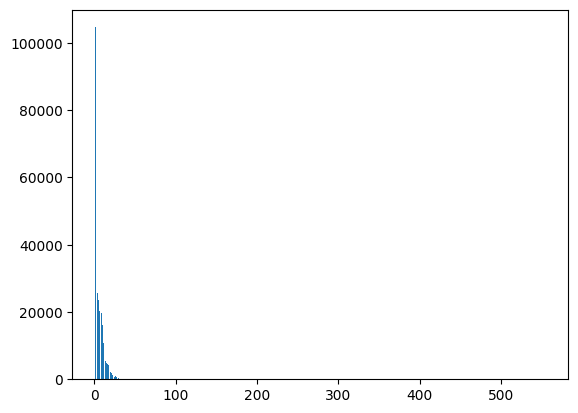

In [12]:
# 这里进行绘图吧
plt.bar([i[0] for i in lst], [i[1] for i in lst])

In [15]:
# 我想看看每个节点有多少比例是下几个节点
for i in range(len(lst)):
    c1 = lst[i][1] # 当前的计数
    c2 = sum([a[1] for a in lst[i+1:]]) # 后边所有的计数
    days = lst[i][0] # 天数
    percent = 100-c1/(c1+c2)*100
    # 输出结果
    print(f'{days}:{percent:.2f}%')

1:73.71%
2:82.60%
3:85.87%
4:87.66%
5:87.15%
6:87.17%
7:85.43%
8:83.03%
9:79.84%
10:79.47%
11:82.66%
12:84.70%
13:84.69%
14:84.99%
15:84.38%
16:83.39%
17:80.55%
18:83.60%
19:80.61%
20:82.75%
21:79.94%
22:85.85%
23:85.18%
24:86.37%
25:84.57%
26:79.38%
27:75.80%
28:74.27%
29:78.32%
30:72.93%
31:81.72%
32:85.42%
33:88.10%
34:82.28%
35:79.74%
36:82.61%
37:83.66%
38:87.09%
39:87.83%
40:82.68%
41:80.63%
42:81.17%
43:91.20%
44:90.35%
45:92.23%
46:90.53%
47:88.37%
48:84.21%
49:87.50%
50:82.14%
51:86.96%
52:90.00%
53:88.89%
54:93.75%
55:96.67%
56:96.55%
59:96.43%
62:92.59%
63:96.00%
64:95.83%
67:95.65%
72:95.45%
76:95.24%
77:95.00%
78:94.74%
79:88.89%
85:93.75%
86:93.33%
87:85.71%
131:91.67%
138:81.82%
150:88.89%
152:87.50%
174:71.43%
184:80.00%
242:75.00%
545:66.67%
546:50.00%
555:0.00%


表明10日均线时一个很强的关键点，突破了就不容易返回。